In [ ]:
# download data from https://drive.google.com/drive/folders/1aDvzXkTN8XeibHVKSMj-bgmHThXzBGho?usp=sharing
# a file called  human_monkey.zip
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## preprocess

In [ ]:
# # Read other species and process: chimp, gorilla, marmoset, rhesus
# human=pd.read_csv('human_data.csv')
# print('done')
# chimp = pd.read_csv('chimp_data.csv')
# print('done')
# gorilla = pd.read_csv('gorilla_data.csv')
# print('done')
# marmoset = pd.read_csv('marmoset_data.csv')
# print('done')
# rhesus = pd.read_csv('rhesus_data.csv')

# # Define convenience function to read & index by gene column (Unnamed: 0)
# def read_species_df(df):
#     df = df.copy()
#     if 'Unnamed: 0' in df.columns:
#         df.index = df['Unnamed: 0'].astype(str)
#         df = df.drop(columns=['Unnamed: 0'])
#     else:
#         df.index = df.index.astype(str)
#     return df

# human_df = read_species_df(human)
# chimp_df = read_species_df(chimp)
# gorilla_df = read_species_df(gorilla)
# marmoset_df = read_species_df(marmoset)
# rhesus_df = read_species_df(rhesus)

In [ ]:
# useful_genes=pd.read_csv('useful_genes(S6).csv',header = None)
# # Filter using useful_genes[0]
# useful = useful_genes[0].astype(str).tolist()
# human_f = human_df.loc[human_df.index.isin(useful)]
# chimp_f = chimp_df.loc[chimp_df.index.isin(useful)]
# gorilla_f = gorilla_df.loc[gorilla_df.index.isin(useful)]
# marmoset_f = marmoset_df.loc[marmoset_df.index.isin(useful)]
# rhesus_f = rhesus_df.loc[rhesus_df.index.isin(useful)]

# # Find intersection of genes present across all species
# common_genes = set(human_f.index) & set(chimp_f.index) & set(gorilla_f.index) & set(marmoset_f.index) & set(rhesus_f.index)
# common_genes = sorted(list(common_genes))
# print('Common genes across species:', len(common_genes))

Common genes across species: 13991


In [ ]:
# # Align and stack horizontally (genes x samples)
# human_al = human_f.loc[common_genes]
# chimp_al = chimp_f.loc[common_genes]
# gorilla_al = gorilla_f.loc[common_genes]
# marmoset_al = marmoset_f.loc[common_genes]
# rhesus_al = rhesus_f.loc[common_genes]

# stacked = pd.concat([human_al, chimp_al, gorilla_al, marmoset_al, rhesus_al], axis=1)
# print('Stacked shape:', stacked.shape)

# # Compute variance across samples and select top 500 most variable genes
# gene_var = stacked.var(axis=1)
# ntop = min(500, len(gene_var))
# top500 = gene_var.sort_values(ascending=False).index[:ntop].tolist()

In [ ]:
# # Remove null/NaN entries from all aligned DataFrames
# print("=== Cleaning null entries ===")
# print("Before cleaning:")
# print(f"human_al: {human_al.shape}, NaN count: {human_al.isnull().sum().sum()}")
# print(f"chimp_al: {chimp_al.shape}, NaN count: {chimp_al.isnull().sum().sum()}")
# print(f"gorilla_al: {gorilla_al.shape}, NaN count: {gorilla_al.isnull().sum().sum()}")
# print(f"marmoset_al: {marmoset_al.shape}, NaN count: {marmoset_al.isnull().sum().sum()}")
# print(f"rhesus_al: {rhesus_al.shape}, NaN count: {rhesus_al.isnull().sum().sum()}")

# # Remove rows (genes) that have any NaN values across all species
# # First, identify genes with NaN in any species
# genes_with_nan = set()
# for df, name in [(human_al, 'human'), (chimp_al, 'chimp'), (gorilla_al, 'gorilla'), 
#                  (marmoset_al, 'marmoset'), (rhesus_al, 'rhesus')]:
#     nan_genes = df.index[df.isnull().any(axis=1)]
#     if len(nan_genes) > 0:
#         print(f"{name}: {len(nan_genes)} genes with NaN values")
#         genes_with_nan.update(nan_genes)

# print(f"Total unique genes with NaN across all species: {len(genes_with_nan)}")

# # Remove genes with NaN from all DataFrames
# if len(genes_with_nan) > 0:
#     clean_genes = [gene for gene in common_genes if gene not in genes_with_nan]
#     print(f"Genes remaining after cleaning: {len(clean_genes)} (removed {len(common_genes) - len(clean_genes)})")
    
#     # Update all aligned DataFrames
#     human_al = human_al.loc[clean_genes]
#     chimp_al = chimp_al.loc[clean_genes]
#     gorilla_al = gorilla_al.loc[clean_genes]
#     marmoset_al = marmoset_al.loc[clean_genes]
#     rhesus_al = rhesus_al.loc[clean_genes]
    
#     # Update common_genes list
#     common_genes = clean_genes
    
#     print("\nAfter cleaning:")
#     print(f"human_al: {human_al.shape}, NaN count: {human_al.isnull().sum().sum()}")
#     print(f"chimp_al: {chimp_al.shape}, NaN count: {chimp_al.isnull().sum().sum()}")
#     print(f"gorilla_al: {gorilla_al.shape}, NaN count: {gorilla_al.isnull().sum().sum()}")
#     print(f"marmoset_al: {marmoset_al.shape}, NaN count: {marmoset_al.isnull().sum().sum()}")
#     print(f"rhesus_al: {rhesus_al.shape}, NaN count: {rhesus_al.isnull().sum().sum()}")
# else:
#     print("No NaN values found in any aligned DataFrames!")

=== Cleaning null entries ===
Before cleaning:
human_al: (13991, 10000), NaN count: 0
chimp_al: (13991, 10000), NaN count: 0
chimp_al: (13991, 10000), NaN count: 0
gorilla_al: (13991, 10000), NaN count: 0
gorilla_al: (13991, 10000), NaN count: 0
marmoset_al: (13991, 11034), NaN count: 0
marmoset_al: (13991, 11034), NaN count: 0
rhesus_al: (13991, 10000), NaN count: 0
rhesus_al: (13991, 10000), NaN count: 0
Total unique genes with NaN across all species: 0
No NaN values found in any aligned DataFrames!
Total unique genes with NaN across all species: 0
No NaN values found in any aligned DataFrames!


Stacked data shape: (13991, 51034)
Data for PCA shape: (51034, 13991)


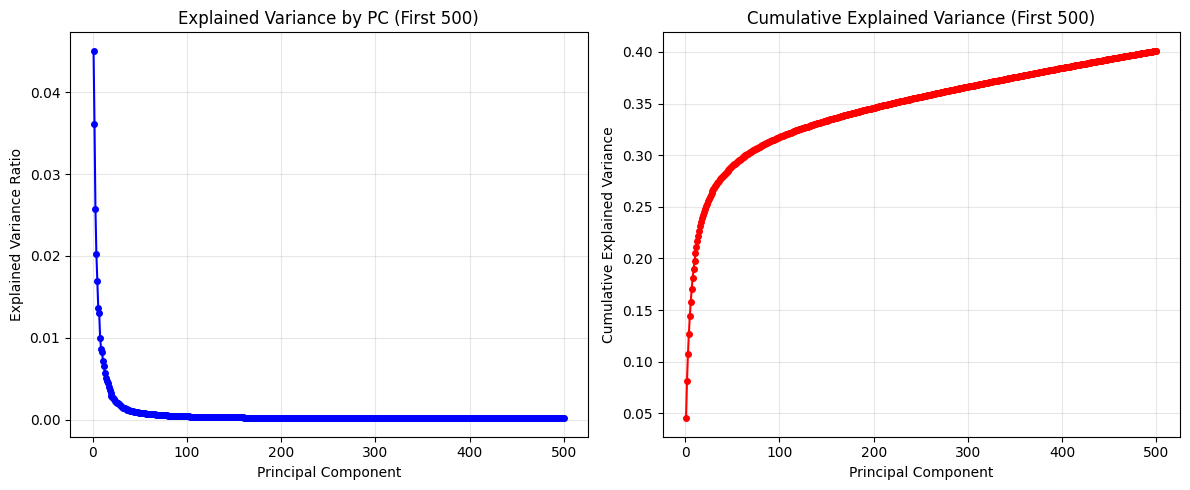

In [ ]:
# # # Perform PCA on stacked data with random_state=418


# # Load the stacked data (we need to go back to the preprocessing section data)
# # The stacked data should be available from earlier preprocessing
# print("Stacked data shape:", stacked.shape)

# # Transpose the data so samples are rows and genes are columns for PCA
# # stacked is (genes x samples), we want (samples x genes)
# X_pca = stacked.T  # Now shape is (samples x genes)
# print("Data for PCA shape:", X_pca.shape)

# # Perform PCA with 500 components and random_state=418
# n_components =500 
# pca = PCA(n_components=n_components, random_state=418, svd_solver='auto')
# X_pca_transformed = pca.fit_transform(X_pca)

# # Recover the principal components (loadings)
# principal_components = pca.components_  # Shape: (n_components, n_features)


# # Plot explained variance
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.plot(range(1, min(501, n_components+1)), pca.explained_variance_ratio_[:500], 'bo-', markersize=4)
# plt.xlabel('Principal Component')
# plt.ylabel('Explained Variance Ratio')
# plt.title('Explained Variance by PC (First 500)')
# plt.grid(True, alpha=0.3)

# plt.subplot(1, 2, 2)
# plt.plot(range(1, min(501, n_components+1)), np.cumsum(pca.explained_variance_ratio_[:500]), 'ro-', markersize=4)
# plt.xlabel('Principal Component')
# plt.ylabel('Cumulative Explained Variance')
# plt.title('Cumulative Explained Variance (First 500)')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [ ]:
# np.save('pc_components.npy', pca.components_)

In [ ]:
# # Recover individual species datasets from PCA
# print("=== Recovering Individual Species Datasets ===")

# # Species information
# species_names = ['human', 'chimp', 'gorilla', 'marmoset', 'rhesus']
# species_sample_counts = [human_al.shape[1], chimp_al.shape[1], gorilla_al.shape[1], 
#                         marmoset_al.shape[1], rhesus_al.shape[1]]

# print("Sample counts per species:", dict(zip(species_names, species_sample_counts)))

# # Split the PCA-transformed data back into individual species
# recovered_species = {}
# start_idx = 0

# for i, (species, n_samples) in enumerate(zip(species_names, species_sample_counts)):
#     end_idx = start_idx + n_samples
    
#     # Extract this species' samples from the PCA-transformed data
#     species_pca_data = X_pca_transformed[start_idx:end_idx, :]  # (n_samples, n_components)
    
#     # Store the recovered data
#     recovered_species[species] = {
#         'pca_data': species_pca_data,
#         'sample_indices': list(range(start_idx, end_idx)),
#         'n_samples': n_samples
#     }
    
#     print(f"{species}: samples {start_idx}-{end_idx-1}, shape: {species_pca_data.shape}")
#     start_idx = end_idx


=== Recovering Individual Species Datasets ===
Sample counts per species: {'human': 10000, 'chimp': 10000, 'gorilla': 10000, 'marmoset': 11034, 'rhesus': 10000}
human: samples 0-9999, shape: (10000, 500)
chimp: samples 10000-19999, shape: (10000, 500)
gorilla: samples 20000-29999, shape: (10000, 500)
marmoset: samples 30000-41033, shape: (11034, 500)
rhesus: samples 41034-51033, shape: (10000, 500)


In [ ]:
# # save datasets with 500 pc
# for species in species_names:
#     np.save(species+'500pc.npy',recovered_species[species]['pca_data'])

In [ ]:
# covs = []
# for species in recovered_species.values():
#     cov_matrix = np.cov(species['pca_data'], rowvar=False)  # Shape: (n_components, n_components)
#     covs.append(cov_matrix)
# np.save("stacked_cov_500_pc",np.stack(covs,axis = 2))

# load functions

In [2]:
import mcpca

In [ ]:
# def plot_B_heatmap(B, title=None, figsize=(6,4), annot=False, cmap='viridis', show_stats=False, 
#                    robust=True, vmin=None, vmax=None):
#     """
#     Plot heatmap of B matrix from tensor decomposition.
    
#     Parameters:
#     -----------
#     B : numpy.ndarray
#         The B matrix to plot (contexts × components)
#     title : str, optional
#         Custom title for the plot
#     figsize : tuple, optional
#         Figure size (width, height)
#     annot : bool, optional
#         Whether to show values in cells
#     cmap : str, optional
#         Colormap name (default: 'inferno' for excellent visibility of shallow values)
#     show_stats : bool, optional
#         Whether to print matrix statistics
#     robust : bool, optional
#         If True, use robust statistics to set color limits (reduces outlier impact)
#     vmin, vmax : float, optional
#         Manual color scale limits (overrides robust if provided)
#     """
#     B_new = B[[0,1,2,4,3],:]
#     import seaborn as sns
    
#     plt.figure(figsize=figsize)

#     contexts = ['human', 'chimp', 'gorilla', 'rhesus','marmoset']
    
#     # Handle color scale to reduce outlier impact
#     if vmin is None or vmax is None:
#         if robust:
#             # Use percentiles to clip extreme values
#             vmin_calc = np.percentile(B_new, 2)   # 2nd percentile
#             vmax_calc = np.percentile(B_new, 98)  # 98th percentile
#             if vmin is None:
#                 vmin = vmin_calc
#             if vmax is None:
#                 vmax = vmax_calc
#         else:
#             if vmin is None:
#                 vmin = B_new.min()
#             if vmax is None:
#                 vmax = B_new.max()
    
#     # Create heatmap (transpose B to put contexts on x-axis)
#     sns.heatmap(B_new.T, 
#                 annot=annot,
#                 cmap=cmap,
#                 vmin=vmin,
#                 vmax=vmax,
#                 cbar_kws={'label': 'B values'},
#                 xticklabels=contexts)  # Component labels
    
#     # Set title
#     if title is None:
#         title = f'Heatmap of B Matrix ({B_new.shape[1]} components × {B_new.shape[0]} contexts)'
#         if robust:
#             title += f'\n(Color scale: {vmin:.3f} to {vmax:.3f}, outliers clipped)'
#     plt.title(title, fontsize=14)
#     plt.xlabel('Contexts', fontsize=12)
#     plt.ylabel('Components', fontsize=12)
#     plt.tight_layout()
#     plt.show()
    
#     # Print statistics if requested
#     if show_stats:
#         print(f"B matrix shape: {B_new.shape}")
#         print(f"B matrix range: [{B_new.min():.4f}, {B_new.max():.4f}]")
#         print(f"Color scale range: [{vmin:.4f}, {vmax:.4f}]")
#         print(f"Number of values below color min: {np.sum(B_new < vmin)} ({100*np.sum(B_new < vmin)/B_new.size:.1f}%)")
#         print(f"Number of values above color max: {np.sum(B_new > vmax)} ({100*np.sum(B_new > vmax)/B_new.size:.1f}%)")
#         print(f"Number of negative values: {np.sum(B_new < 0)} / {B_new.size} ({100*np.sum(B_new < 0)/B_new.size:.1f}%)")
#         print(f"Number of positive values: {np.sum(B_new > 0)} / {B_new.size} ({100*np.sum(B_new > 0)/B_new.size:.1f}%)")

In [3]:
def create_tree_from_B(B, distance_metric='euclidean', linkage_method='ward', figsize=(10, 6), method = 'MCPCA'):
    """
    Create a phylogenetic tree (dendrogram) from B matrix using hierarchical clustering.
    
    Parameters:
    -----------
    B : numpy.ndarray
        The B matrix (contexts × components)
    distance_metric : str
        Distance metric ('euclidean', 'cosine', 'correlation', 'manhattan')
    linkage_method : str
        Linkage method ('ward', 'single', 'complete', 'average')
    figsize : tuple
        Figure size for the dendrogram
    
    Returns:
    --------
    linkage_matrix : numpy.ndarray
        Linkage matrix from hierarchical clustering
    distances : numpy.ndarray
        Distance matrix between species
    """
    from scipy.cluster.hierarchy import dendrogram, linkage
    from scipy.spatial.distance import pdist, squareform
    from sklearn.metrics.pairwise import pairwise_distances
    import matplotlib.pyplot as plt
    
    contexts = ['human', 'chimp', 'gorilla', 'marmoset', 'rhesus']
    
    # Compute pairwise distances between species (rows of B)
    if distance_metric == 'correlation':
        # Use correlation distance (1 - correlation)
        correlation_matrix = np.corrcoef(B)
        distances = 1 - correlation_matrix
        # Ensure diagonal is 0 and matrix is symmetric
        np.fill_diagonal(distances, 0)
        distances = (distances + distances.T) / 2
        # Convert to condensed distance matrix for scipy
        condensed_distances = squareform(distances)
    else:
        # Use sklearn for other distance metrics
        distances = pairwise_distances(B, metric=distance_metric)
        distances = 1/2*(distances+distances.T)
        condensed_distances = squareform(distances)
        
    
    # Perform hierarchical clustering
    # Note: ward method requires euclidean distance
    if linkage_method == 'ward' and distance_metric != 'euclidean':
        print(f"Warning: Ward linkage requires euclidean distance. Switching to 'average' linkage.")
        linkage_method = 'average'
    
    linkage_matrix = linkage(condensed_distances, method=linkage_method)
    
    # Create dendrogram
    plt.figure(figsize=figsize)
    dendrogram(linkage_matrix, labels=contexts, leaf_rotation=45, leaf_font_size=12,color_threshold=0,above_threshold_color='black')
    plt.title(f'Phylogenetic Tree ({method})', 
              fontsize=14, fontweight='bold')
    plt.ylabel('Distance', fontsize=12)
    plt.xlabel('Species', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Print distance matrix
    print("Distance Matrix between Species:")
    print("=" * 50)
    distance_df = pd.DataFrame(distances, index=contexts, columns=contexts)
    print(distance_df.round(3))
    
    return linkage_matrix, distances

![Screenshot 2025-10-09 at 13.16.55.png](<attachment:Screenshot 2025-10-09 at 13.16.55.png>)
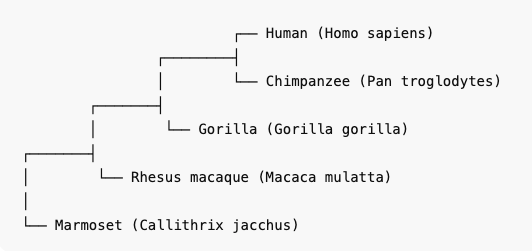

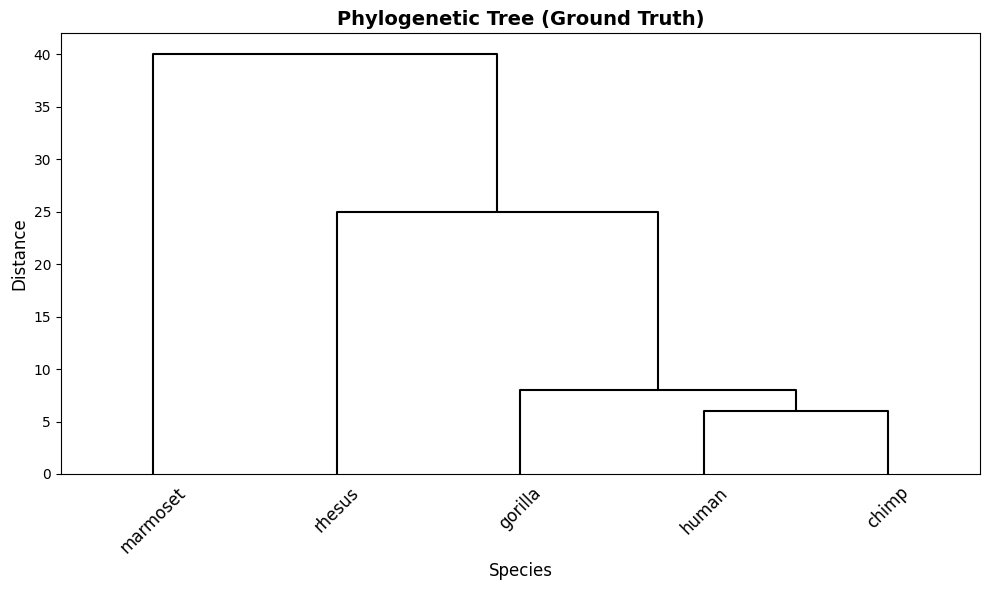

Distance Matrix between Species:
          human  chimp  gorilla  marmoset  rhesus
human       0.0    6.0      8.0      40.0    25.0
chimp       6.0    0.0      8.0      40.0    25.0
gorilla     8.0    8.0      0.0      40.0    25.0
marmoset   40.0   40.0     40.0       0.0    40.0
rhesus     25.0   25.0     25.0      40.0     0.0


(array([[ 0.,  1.,  6.,  2.],
        [ 2.,  5.,  8.,  3.],
        [ 4.,  6., 25.,  4.],
        [ 3.,  7., 40.,  5.]]),
 array([[ 0.,  6.,  8., 40., 25.],
        [ 6.,  0.,  8., 40., 25.],
        [ 8.,  8.,  0., 40., 25.],
        [40., 40., 40.,  0., 40.],
        [25., 25., 25., 40.,  0.]]))

In [4]:
import numpy as np
D = np.array([
    [ 0,  6,  8, 40, 25],
    [ 6,  0,  8, 40, 25],
    [ 8,  8,  0, 40, 25],
    [40, 40, 40,  0, 40],
    [25, 25, 25, 40,  0],
], dtype=float)

def classical_mds(D):
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n))/n
    B = -0.5 * J @ (D**2) @ J
    w, v = np.linalg.eigh(B)
    idx = np.argsort(w)[::-1]
    w, v = w[idx], v[:, idx]
    pos = w > 1e-12
    X = v[:, pos] @ np.diag(np.sqrt(w[pos]))
    return X

B = classical_mds(D)  # rows correspond to labels above
create_tree_from_B(B,distance_metric='euclidean', linkage_method='complete', figsize=(10, 6), method = 'Ground Truth')

# 500 PC

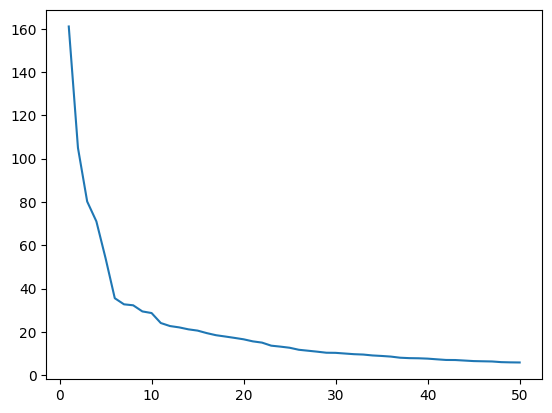

In [8]:
T = np.load("stacked_cov_500_pc.npy")
U,D,V = np.linalg.svd(T.reshape(500,-1))
plt.plot(range(1,51),D[:50])

In [9]:
def plot_rank_stability_analysis(rank_range, rank_similarities,
                                figsize=(12, 8), show_error_bars=True):
    """
    Plot the rank stability analysis results with error bars and detailed visualization.
    
    Parameters:
    -----------
    rank_range : range or list
        Range of ranks tested
    rank_similarities : dict
        Detailed similarity statistics from compute_rank_stability_analysis
    avg_similarities : list
        Average similarities for each rank
    figsize : tuple
        Figure size
    show_error_bars : bool
        Whether to show error bars (standard deviation)
    """
    ranks = list(rank_range)
    
    # Extract statistics
    means = [rank_similarities[r]['mean'] for r in ranks]
    stds = [rank_similarities[r]['std'] for r in ranks]
    mins = [rank_similarities[r]['min'] for r in ranks]
    maxs = [rank_similarities[r]['max'] for r in ranks]
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Main plot with error bars
    if show_error_bars:
        ax1.errorbar(ranks, means, yerr=stds, 
                    marker='o', markersize=8, linewidth=2, capsize=5,
                    label='Mean ± Std Dev', color='blue', alpha=0.8)
    else:
        ax1.plot(ranks, means, marker='o', markersize=8, linewidth=2, 
                label='Mean Similarity', color='blue')
    
    # Add min/max envelope
    ax1.fill_between(ranks, mins, maxs, alpha=0.2, color='blue', 
                    label='Min-Max Range')
    
    ax1.set_xlabel('Tensor Rank', fontsize=14)
    ax1.set_ylabel('Cosine Similarity between A matrices', fontsize=14)
    ax1.set_title('Tensor Decomposition Stability Analysis\n(Higher = More Stable)', 
                 fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    
    # Add horizontal line at 0.9 (high stability threshold)
    ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.7, 
               label='High Stability (0.9)')
    ax1.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7,
               label='Moderate Stability (0.8)')
    
    # Set y-axis limits for better visualization
    y_min = max(0.0, min(mins) - 0.05)
    y_max = min(1.0, max(maxs) + 0.05)
    ax1.set_ylim(y_min, y_max)
    
    # Second subplot: Box plot showing distribution for each rank
    box_data = [rank_similarities[r]['similarities'] for r in ranks]
    
    bp = ax2.boxplot(box_data, positions=ranks, widths=0.5, patch_artist=True)
    
    # Color the boxes based on stability
    for i, (patch, mean_val) in enumerate(zip(bp['boxes'], means)):
        if mean_val >= 0.9:
            patch.set_facecolor('lightgreen')
        elif mean_val >= 0.8:
            patch.set_facecolor('lightyellow') 
        else:
            patch.set_facecolor('lightcoral')
    
    ax2.set_xlabel('Tensor Rank', fontsize=14)
    ax2.set_ylabel('Cosine Similarity Distribution', fontsize=14)
    ax2.set_title('Similarity Distribution by Rank\n(Box Plot)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add stability threshold lines to box plot
    # ax2.axhline(y=0.9, color='red', linestyle='--', alpha=0.7)
    ax2.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

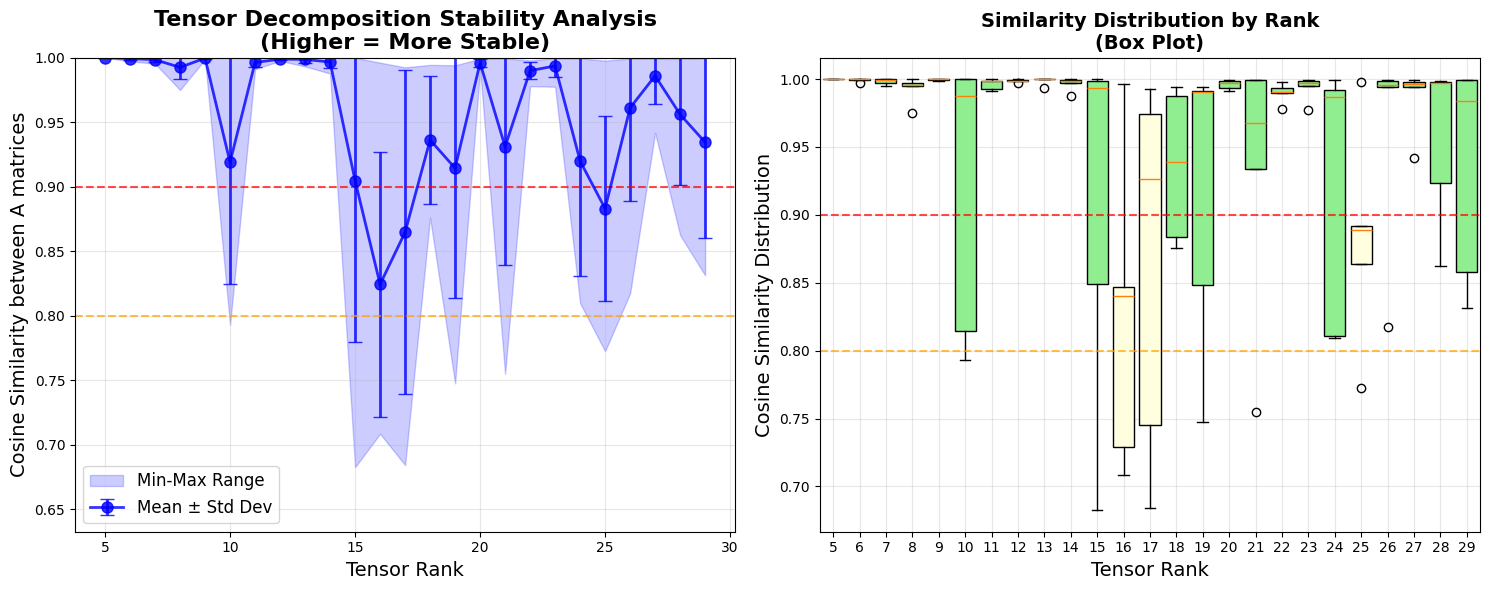

In [ ]:
# test_ranks = list(range(5,30))
# n_pairs = 5  # Number of random seed pairs to test per rank

# # Run the analysis
# _, rank_stats = choose_rank(
#     T, 
#     test_ranks, 
#     n_seed_pairs=n_pairs, 
#     stats=True
# )
# plot_rank_stability_analysis(test_ranks, rank_stats,
#                            figsize=(15, 6), show_error_bars=True)

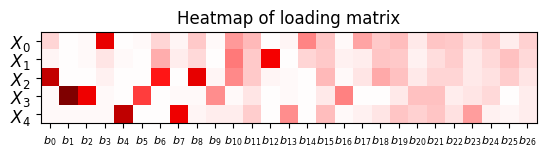

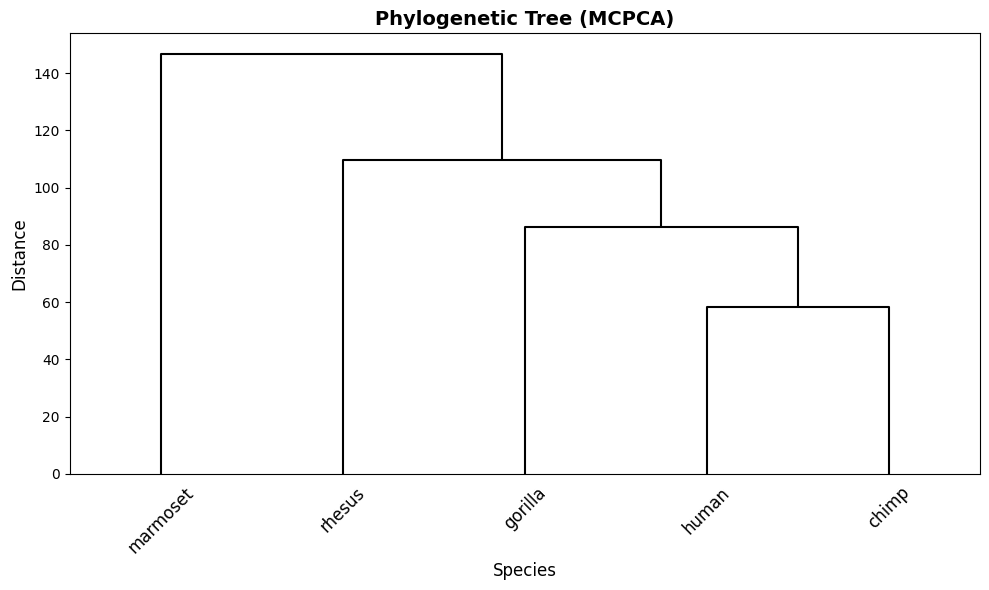

Distance Matrix between Species:
            human    chimp  gorilla  marmoset   rhesus
human       0.000   58.287   86.365   132.127   89.369
chimp      58.287    0.000   86.135   129.456   87.268
gorilla    86.365   86.135    0.000   146.547  109.571
marmoset  132.127  129.456  146.547     0.000  135.066
rhesus     89.369   87.268  109.571   135.066    0.000


In [ ]:
np.random.seed(0)
A,B_nnls = mcpca.MCPCA_decompose(T, 27,plot_B = True)
result = create_tree_from_B(T.reshape(-1,5).T,distance_metric='euclidean', linkage_method='complete', figsize=(10, 6))

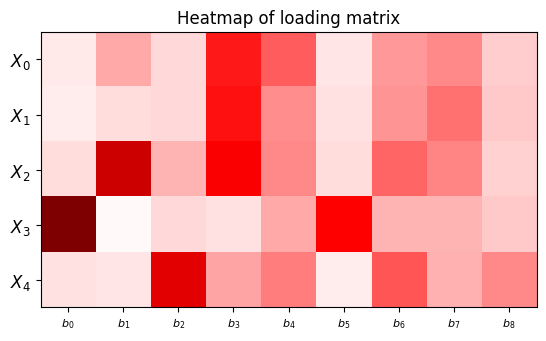

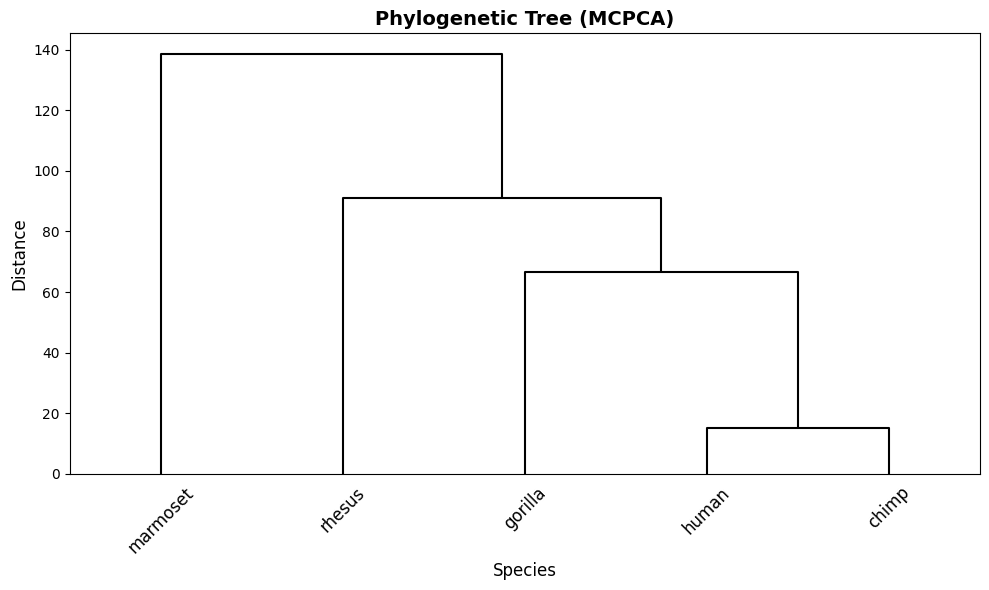

Distance Matrix between Species:
            human    chimp  gorilla  marmoset   rhesus
human       0.000   15.267   57.316   119.779   67.310
chimp      15.267    0.000   66.742   119.507   67.378
gorilla    57.316   66.742    0.000   138.432   91.182
marmoset  119.779  119.507  138.432     0.000  125.667
rhesus     67.310   67.378   91.182   125.667    0.000


In [ ]:
np.random.seed(0)
A,B_nnls1 = mcpca.MCPCA_decompose(T,9,plot_B = True)
result1 = create_tree_from_B(B_nnls1,distance_metric='euclidean', linkage_method='complete', figsize=(10, 6))

## comapre trees from different methods

In [13]:
# old functions output if two trees are topologically the same

def compare_phylogenetic_trees(B1, B2=None, dist_metric='euclidean', 
                              link_method='complete', 
                              true_tree=None):
    """
    Compare phylogenetic trees from different B matrices or methods.
    Returns:
    --------
    True or False
    """
    from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
    from scipy.spatial.distance import pdist, squareform
    from sklearn.metrics.pairwise import pairwise_distances
    import matplotlib.pyplot as plt
    
    contexts = ['human', 'chimp', 'gorilla', 'marmoset', 'rhesus']
    results = {}
    
    # Helper function to compute linkage matrix
    def compute_linkage_matrix(B, dist_metric, link_method):
        distances = pairwise_distances(B, metric=dist_metric)
        distances = (distances + distances.T) / 2
        condensed_distances = squareform(distances)       
        linkage_matrix = linkage(condensed_distances, method=link_method)
        return linkage_matrix, distances
    
    linkage_matrix, distances = compute_linkage_matrix(B1, dist_metric, link_method)
    
    if true_tree is not None:
        return compare_two_linkage_matrices(linkage_matrix, true_tree)
    if B2 is not None:
        linkage_matrix2, distances2 = compute_linkage_matrix(B2, dist_metric, link_method)
        return compare_two_linkage_matrices(linkage_matrix, linkage_matrix2)
    

def get_tree_structure(linkage_matrix):
    """Extract the tree topology as a tuple of merges."""
    merges = []
    for row in linkage_matrix:
        merges.append((int(row[0]), int(row[1])))
    return tuple(merges)


def compare_two_linkage_matrices(link1, link2):
    """
    Returns:
    --------
    comparison : dict
        Contains topology_match
    """
    
    # Check if tree topologies are identical
    struct1 = get_tree_structure(link1)
    struct2 = get_tree_structure(link2)
    score = 0
    for i in range(len(struct1)):
        if struct1[i]!=struct2[i]:
            score+=1
   
    return score

true_primate_tree = np.array([
    [0, 1, 1.0, 2],      # Step 1: human(0) + chimp(1) merge first (closest relatives)
    [2, 5, 2.0, 3],      # Step 2: gorilla(2) joins human-chimp cluster(5) 
    [4, 6, 3.0, 4],      # Step 3: rhesus(4) joins the great ape cluster(6)
    [3, 7, 4.0, 5]       # Step 4: marmoset(3) joins all others (most distant)
])

Text(0.5, 1.0, 'Topological Distance to True Tree vs Rank (MCPCA)')

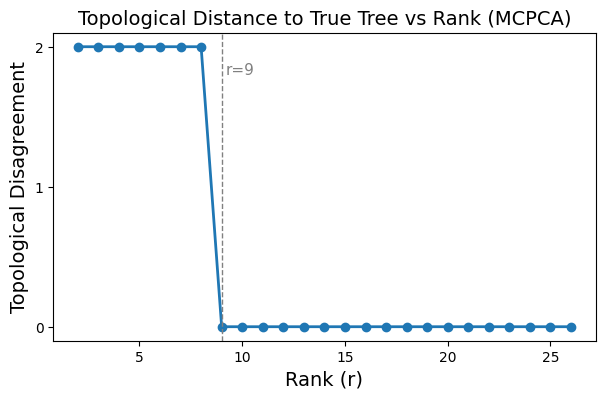

In [ ]:
rf_distances_mcpca = []
for r in range(2,27):
    np.random.seed(0)
    A,B_nnls = mcpca.MCPCA_decompose(T, r)
    output = compare_phylogenetic_trees(B_nnls, true_tree=true_primate_tree, dist_metric='euclidean', link_method='complete');
    rf_distances_mcpca.append(output)      

plt.figure(figsize=(7,4))
plt.plot(range(2,27), rf_distances_mcpca,marker = 'o',linewidth = 2)
plt.xlabel('Rank (r)',fontsize = 14)
plt.ylabel('Topological Disagreement',fontsize = 14)
plt.yticks(range(0,max(rf_distances_mcpca)+1))
plt.axvline(x=9, color='gray', linestyle='--', linewidth=1)
plt.text(9.2, 1.8, 'r=9', fontsize=11, color='gray')
plt.title('Topological Distance to True Tree vs Rank (MCPCA)',fontsize = 14)

Text(0.5, 1.0, 'Topological Distance to True Tree vs Rank (PCA Cov)')

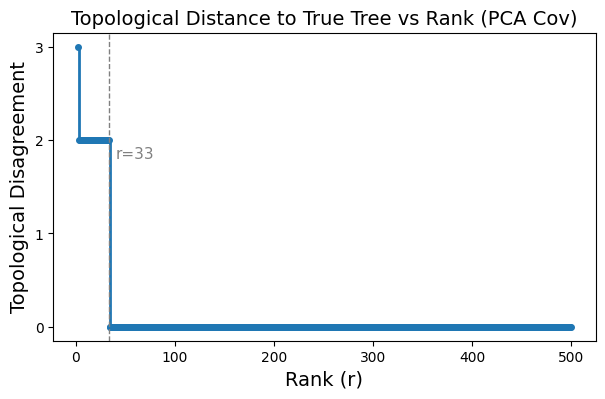

In [17]:
# varying PCs see if we get correct tree and use flattened covariances
# from 33 PCs on, we can recover the tree
human = np.load('human500pc.npy')
chimp = np.load('chimp500pc.npy')
gorilla = np.load('gorilla500pc.npy')
rhesus = np.load('rhesus500pc.npy')
marmoset = np.load('marmoset500pc.npy')
datasets = [human, chimp, gorilla, marmoset, rhesus]
rf_distances = []

for i in range(2,501):
    # print(i)
    covs =[]
    for dataset in datasets:
        subdf = dataset[:,:i]
        covs.append(np.cov(subdf.T))
    T = np.stack(covs,axis = 2).reshape(-1,5).T

    output = compare_phylogenetic_trees(T, true_tree=true_primate_tree, dist_metric='euclidean', link_method='complete');
    rf_distances.append(output)       

plt.figure(figsize=(7,4))
plt.plot(range(2,501), rf_distances[:499],linewidth = 2,drawstyle='steps-post',marker = 'o',markersize=4)
plt.xlabel('Rank (r)',fontsize = 14)
plt.ylabel('Topological Disagreement',fontsize = 14)
plt.yticks(range(0,max(rf_distances)+1))
plt.axvline(x=33, color='gray', linestyle='--', linewidth=1)
plt.text(40, 1.8, 'r=33', fontsize=11, color='gray')
plt.title('Topological Distance to True Tree vs Rank (PCA Cov)',fontsize = 14)


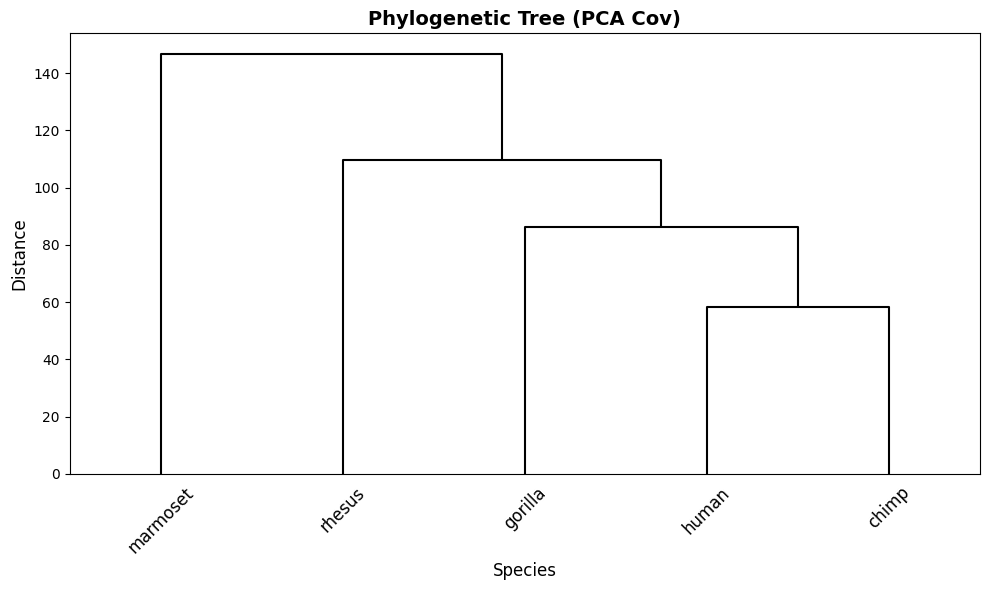

Distance Matrix between Species:
            human    chimp  gorilla  marmoset   rhesus
human       0.000   58.287   86.365   132.127   89.369
chimp      58.287    0.000   86.135   129.456   87.268
gorilla    86.365   86.135    0.000   146.547  109.571
marmoset  132.127  129.456  146.547     0.000  135.066
rhesus     89.369   87.268  109.571   135.066    0.000


(array([[  0.        ,   1.        ,  58.28693313,   2.        ],
        [  2.        ,   5.        ,  86.36531219,   3.        ],
        [  4.        ,   6.        , 109.57136159,   4.        ],
        [  3.        ,   7.        , 146.54726089,   5.        ]]),
 array([[  0.        ,  58.28693313,  86.36531219, 132.12694773,
          89.36927532],
        [ 58.28693313,   0.        ,  86.13534939, 129.4557956 ,
          87.26826124],
        [ 86.36531219,  86.13534939,   0.        , 146.54726089,
         109.57136159],
        [132.12694773, 129.4557956 , 146.54726089,   0.        ,
         135.06604239],
        [ 89.36927532,  87.26826124, 109.57136159, 135.06604239,
           0.        ]]))

In [18]:
create_tree_from_B(T,distance_metric='euclidean', linkage_method='complete', figsize=(10, 6), method = 'PCA Cov')

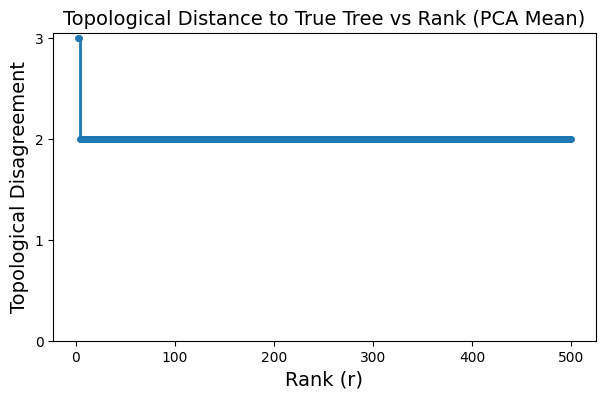

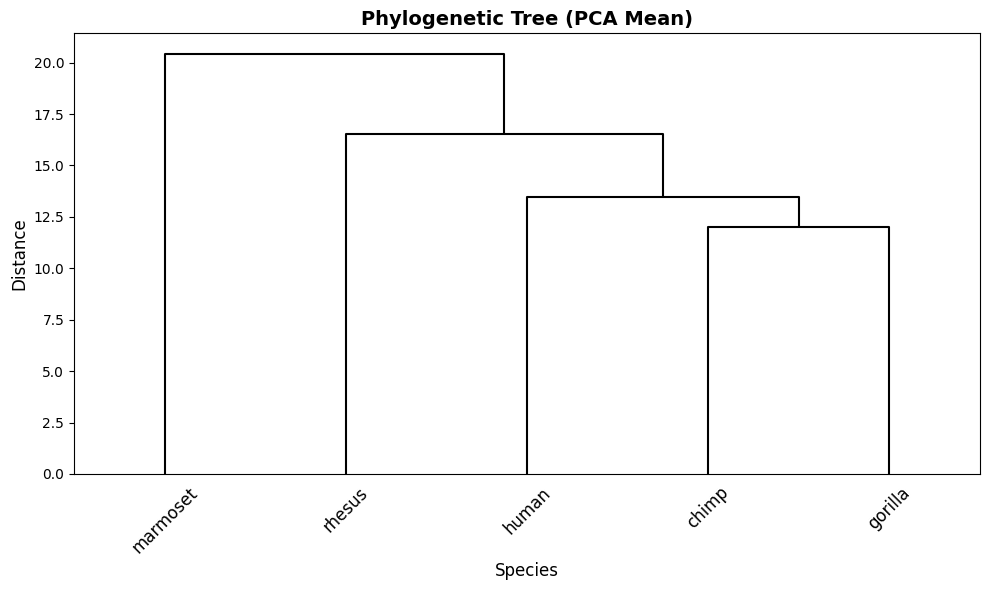

Distance Matrix between Species:
           human   chimp  gorilla  marmoset  rhesus
human      0.000  13.473   13.022    17.804  15.005
chimp     13.473   0.000   12.004    20.392  16.341
gorilla   13.022  12.004    0.000    20.405  16.515
marmoset  17.804  20.392   20.405     0.000  18.022
rhesus    15.005  16.341   16.515    18.022   0.000


(array([[ 1.        ,  2.        , 12.00441881,  2.        ],
        [ 0.        ,  5.        , 13.47281642,  3.        ],
        [ 4.        ,  6.        , 16.51474557,  4.        ],
        [ 3.        ,  7.        , 20.4051739 ,  5.        ]]),
 array([[ 0.        , 13.47281642, 13.02189054, 17.80356009, 15.00543469],
        [13.47281642,  0.        , 12.00441881, 20.39154521, 16.34129234],
        [13.02189054, 12.00441881,  0.        , 20.4051739 , 16.51474557],
        [17.80356009, 20.39154521, 20.4051739 ,  0.        , 18.02156628],
        [15.00543469, 16.34129234, 16.51474557, 18.02156628,  0.        ]]))

In [16]:
# form tree from mean of PCs per species
# can not recover correct tree 
datasets = [human, chimp, gorilla, marmoset, rhesus]
rf_distances = []

for i in range(2,501):
    means =[]
    for dataset in datasets:
        subdf = dataset[:,:i]
        means.append(np.mean(subdf, axis=0))
    T = np.stack(means,axis = 0)
    output = compare_phylogenetic_trees(T, true_tree=true_primate_tree, dist_metric='euclidean', link_method='complete');
    rf_distances.append(output)       


plt.figure(figsize=(7,4))
plt.plot(range(2,501), rf_distances[:499],linewidth = 2,drawstyle='steps-post',marker = 'o',markersize=4)
plt.xlabel('Rank (r)',fontsize = 14)
plt.ylabel('Topological Disagreement',fontsize = 14)
plt.yticks(range(0,max(rf_distances)+1))
# plt.axvline(x=33, color='gray', linestyle='--', linewidth=1)
# plt.text(40, 1.8, 'r=33', fontsize=11, color='gray')
plt.title('Topological Distance to True Tree vs Rank (PCA Mean)',fontsize = 14)

create_tree_from_B(T,distance_metric='euclidean', linkage_method='complete', figsize=(10, 6),method = 'PCA Mean')

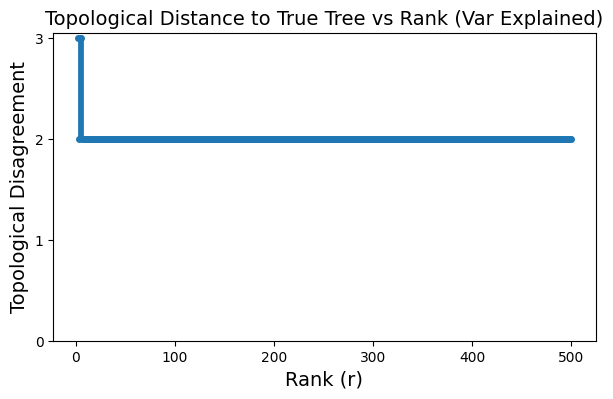

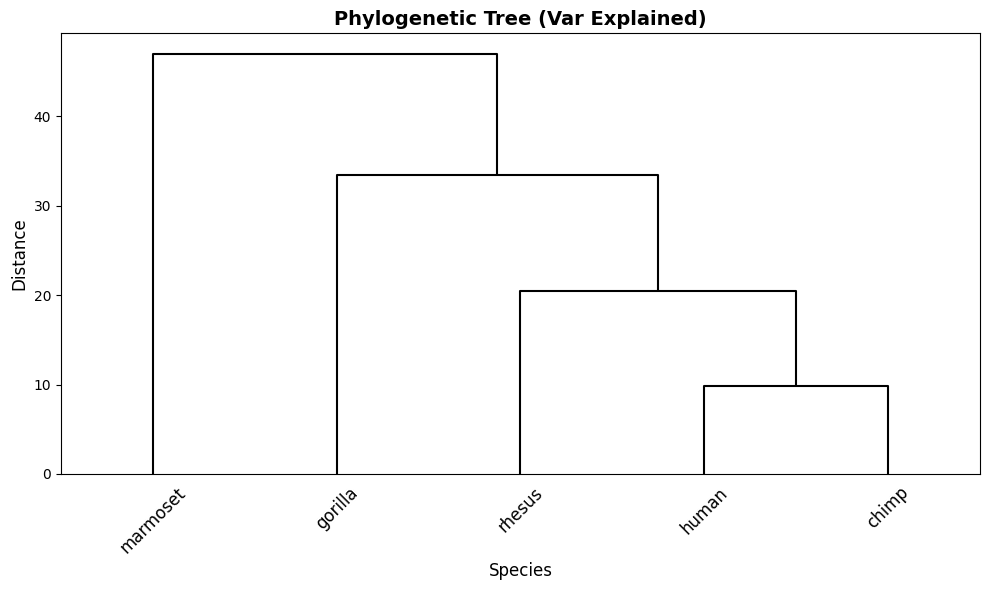

Distance Matrix between Species:
           human   chimp  gorilla  marmoset  rhesus
human      0.000   9.832   28.786    46.704  20.495
chimp      9.832   0.000   33.386    46.338  19.693
gorilla   28.786  33.386    0.000    46.938  31.445
marmoset  46.704  46.338   46.938     0.000  38.993
rhesus    20.495  19.693   31.445    38.993   0.000


(array([[ 0.        ,  1.        ,  9.83197931,  2.        ],
        [ 4.        ,  5.        , 20.49505803,  3.        ],
        [ 2.        ,  6.        , 33.38609257,  4.        ],
        [ 3.        ,  7.        , 46.93815123,  5.        ]]),
 array([[ 0.        ,  9.83197931, 28.78561434, 46.70400573, 20.49505803],
        [ 9.83197931,  0.        , 33.38609257, 46.33788808, 19.69333118],
        [28.78561434, 33.38609257,  0.        , 46.93815123, 31.44505764],
        [46.70400573, 46.33788808, 46.93815123,  0.        , 38.99256309],
        [20.49505803, 19.69333118, 31.44505764, 38.99256309,  0.        ]]))

In [ ]:
# form tree from variance explained by each PC direction
# can not recover correct tree until we use all 500 PCs
# 500*x
datasets = [human, chimp, gorilla, marmoset, rhesus]

rf_distances = []
for i in range(2,501):
    var_explained = []
    for dataset in datasets:
        subdf = dataset[:,:i]
        vars = []
        for j in range(i):
            pc = subdf[:,j]
            var = np.var(pc)
            vars.append(var)
        var_explained.append(vars)
        
    T = np.array(var_explained)
    output = compare_phylogenetic_trees(T, true_tree=true_primate_tree, dist_metric='euclidean', link_method='complete');
    rf_distances.append(output)       





plt.figure(figsize=(7,4))
plt.plot(range(2,501), rf_distances[:499],linewidth = 2,drawstyle='steps-post',marker = 'o',markersize=4)
plt.xlabel('Rank (r)',fontsize = 14)
plt.ylabel('Topological Disagreement',fontsize = 14)
plt.yticks(range(0,max(rf_distances)+1))
# plt.axvline(x=33, color='gray', linestyle='--', linewidth=1)
# plt.text(40, 1.8, 'r=33', fontsize=11, color='gray')
plt.title('Topological Distance to True Tree vs Rank (Var Explained)',fontsize = 14)

create_tree_from_B(T,distance_metric='euclidean', linkage_method='complete', figsize=(10, 6),method = 'Var Explained')